# Live portfolio tearsheet

Reads the `performance.live_log` ledger and displays portfolio-first metrics,
then per-strategy sleeves (starting with `s1_equities`).

Requires equity rows from the S1 paper runner and/or
`python -m performance.eod_snapshot` (or `09_performance/eod_snapshot.py`).


## 0. Imports & Config


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from performance.live_log import (
    STRATEGY_S1_EQUITIES,
    get_meta,
    load_equity_daily,
    load_fills,
    load_signals,
    portfolio_equity_series,
    strategy_equity_series,
)
from performance.metrics import (
    equity_to_returns,
    live_portfolio_metrics,
    live_strategy_metrics,
    plot_rolling_metrics,
    summary_metrics_table,
)

ROLLING_LOOKBACK = 21
FREQ = "d"
YEAR_FREQ = "252d"

meta = get_meta()
sleeve_ids = list((meta.get("sleeve_weights") or {STRATEGY_S1_EQUITIES: 1.0}).keys())
print("portfolio_go_live=", meta.get("portfolio_go_live"))
print("sleeve_weights=", meta.get("sleeve_weights"))
print("sleeves=", sleeve_ids)


portfolio_go_live= None
sleeve_weights= {'s1_equities': 1.0}
sleeves= ['s1_equities']


## 1. Data Loading


In [2]:
equity_daily = load_equity_daily()
port_equity = portfolio_equity_series()

if equity_daily.empty or port_equity.empty:
    raise SystemExit(
        "live_log equity_daily is empty. Run the S1 paper runner and/or "
        "`python -m performance.eod_snapshot` before this tearsheet."
    )

display(equity_daily.tail())
port_equity.tail()


,date,level,strategy_id,equity,allocated_equity,cash
0,2026-08-17,portfolio,,99787.860000,99787.86,100064.54
1,2026-08-17,strategy,s1_equities,99787.860000,99787.86,NaN
2,2026-08-21,portfolio,,99404.570000,99404.57,100064.03
3,2026-08-21,strategy,s1_equities,99687.690901,99404.57,NaN


date
2026-08-17    99787.86
2026-08-21    99404.57
Name: equity, dtype: float64

## 2. Portfolio Metrics


,portfolio
sharpe,NaN
sortino,NaN
calmar,NaN
max_drawdown,0.0


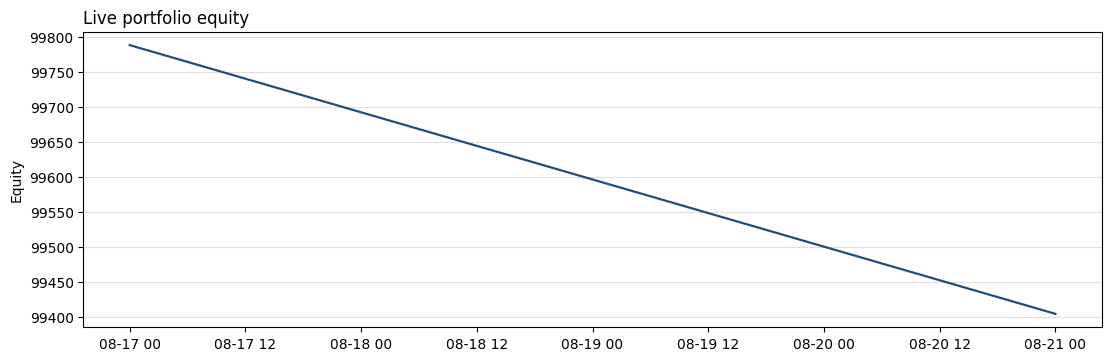

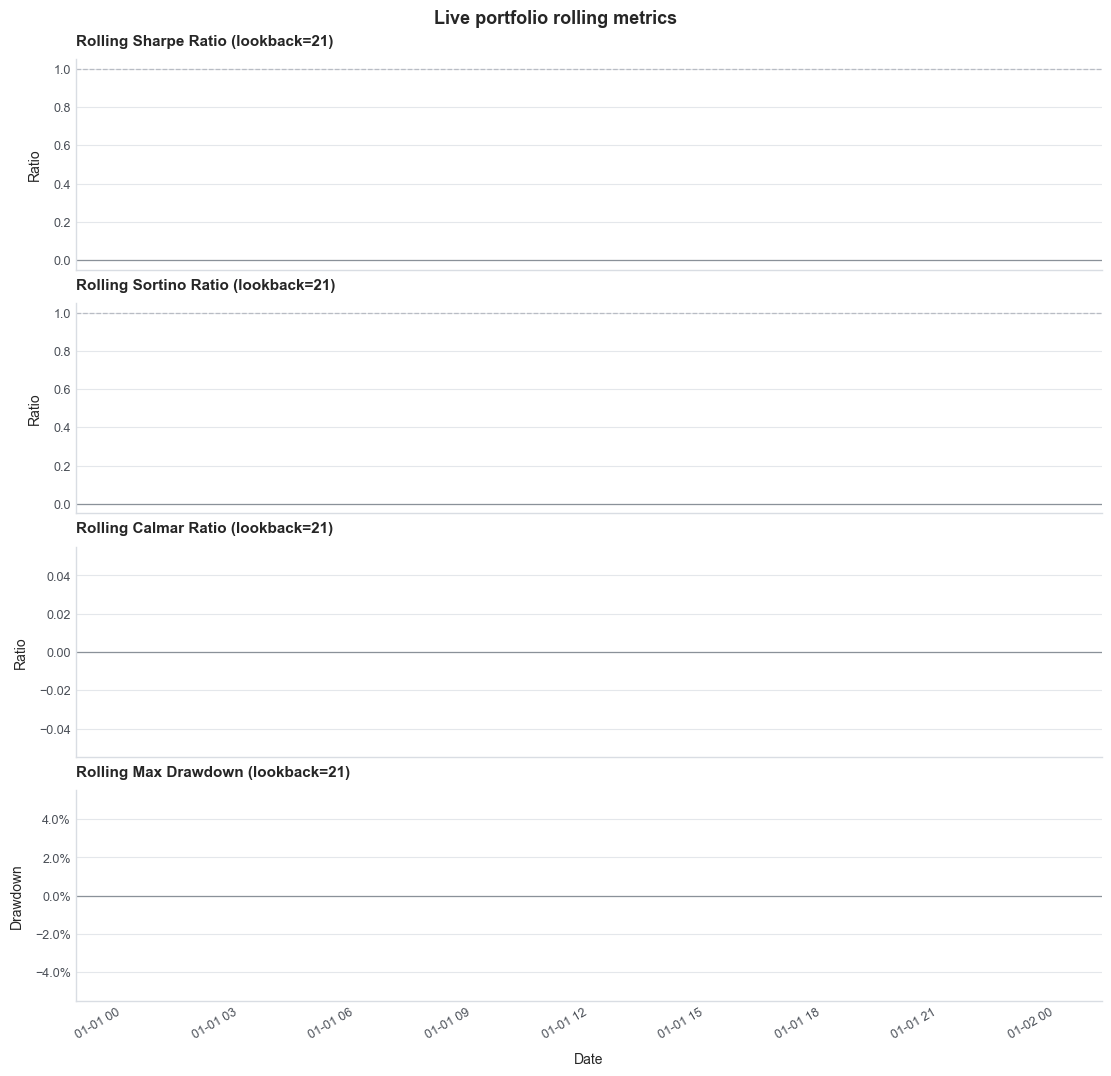

In [3]:
port = live_portfolio_metrics(freq=FREQ, year_freq=YEAR_FREQ)
if port["summary"] is None:
    raise SystemExit(
        "Need at least two portfolio equity points to compute returns/metrics."
    )

display(port["summary"].to_frame("portfolio"))

fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.plot(port["equity"].index, port["equity"].values, color="#1f4e79", lw=1.6)
ax.set_title("Live portfolio equity", loc="left")
ax.set_ylabel("Equity")
ax.grid(True, axis="y", alpha=0.4)
plt.show()

plot_rolling_metrics(
    port["returns"],
    ROLLING_LOOKBACK,
    freq=FREQ,
    year_freq=YEAR_FREQ,
    title="Live portfolio rolling metrics",
)


## 3. Per-Strategy Metrics



=== s1_equities ===


,s1_equities
sharpe,NaN
sortino,NaN
calmar,NaN
max_drawdown,0.0


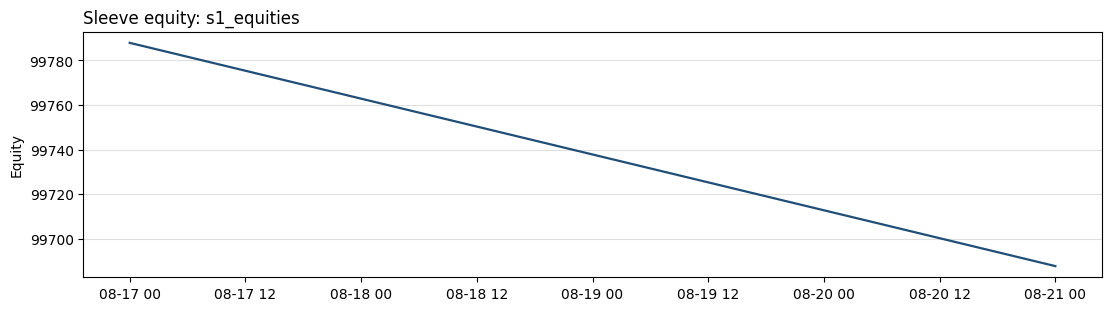

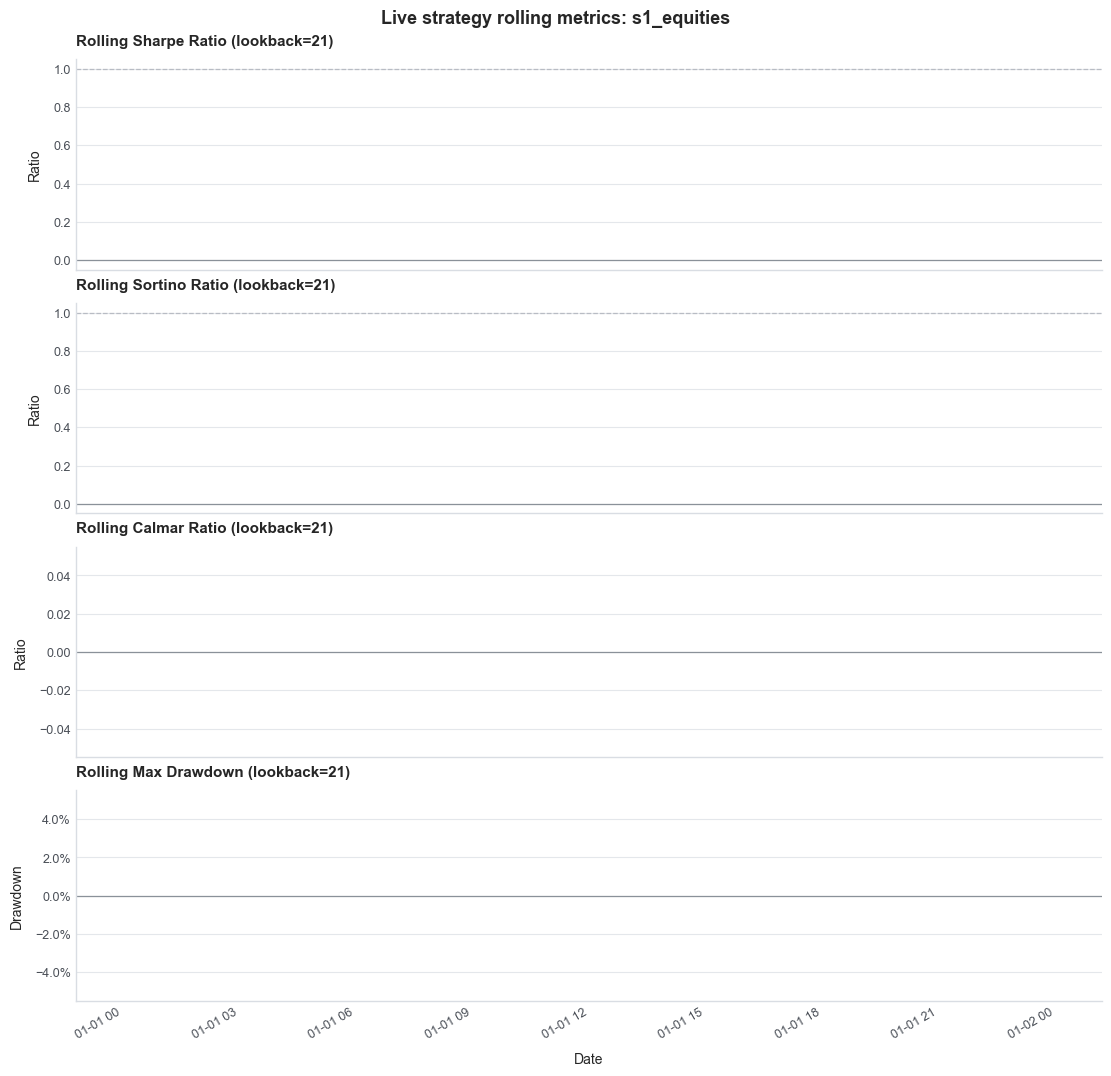

,s1_equities
sharpe,NaN
sortino,NaN
calmar,NaN
max_drawdown,0.0


In [4]:
summaries = {}
for sid in sleeve_ids:
    out = live_strategy_metrics(sid, freq=FREQ, year_freq=YEAR_FREQ)
    print(f"\n=== {sid} ===")
    if out["summary"] is None:
        print("Insufficient sleeve equity history.")
        continue
    summaries[sid] = out["summary"]
    display(out["summary"].to_frame(sid))

    fig, ax = plt.subplots(figsize=(11, 3.0), constrained_layout=True)
    ax.plot(out["equity"].index, out["equity"].values, color="#1f4e79", lw=1.6)
    ax.set_title(f"Sleeve equity: {sid}", loc="left")
    ax.set_ylabel("Equity")
    ax.grid(True, axis="y", alpha=0.4)
    plt.show()

    plot_rolling_metrics(
        out["returns"],
        ROLLING_LOOKBACK,
        freq=FREQ,
        year_freq=YEAR_FREQ,
        title=f"Live strategy rolling metrics: {sid}",
    )

if summaries:
    display(pd.DataFrame(summaries))


## 4. Recent Signals & Fills (Audit)


In [5]:
signals = load_signals()
fills = load_fills()

print(f"signals rows={len(signals)}  fills rows={len(fills)}")
if not signals.empty:
    display(signals.sort_values(["decision_date", "ticker"]).tail(20))
if not fills.empty:
    display(fills.sort_values("ts").tail(20))


signals rows=194  fills rows=81


,ts,decision_date,strategy_id,broker_id,ticker,score,weight,feature_date,run_id
174,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,ROST,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
175,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,RRC,0.518052,0.011533,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
176,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,SBUX,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
177,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,SCHW,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
178,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,SLB,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
179,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,STT,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
180,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,T,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
181,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,TGT,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
182,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,TJX,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
183,2026-08-17 13:59:03.386635,2026-08-17,s1_equities,alpaca,TRV,NaN,0.000000,2026-08-14,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6


,ts,strategy_id,broker_id,ticker,side,qty,price,order_id,fill_type,run_id
67,2026-08-17 13:59:23.665293,s1_equities,alpaca,GILD,buy,0.0,164.70,d21ef766-b7c7-4a9c-8fd5-30394dc83899,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
78,2026-08-17 13:59:23.665293,s1_equities,alpaca,NVDA,sell,0.0,181.02,9a4397dc-0b79-428b-8f07-fdbff80a4cb7,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
73,2026-08-17 13:59:23.665293,s1_equities,alpaca,MRK,buy,0.0,162.65,17978175-e217-4402-a903-486282ce16c8,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
66,2026-08-17 13:59:23.665293,s1_equities,alpaca,FSLR,sell,0.0,180.96,3caebed5-8448-4158-ab0f-4c30390dcade,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
59,2026-08-17 13:59:23.665293,s1_equities,alpaca,COP,buy,0.0,151.34,799b0188-2166-48fa-b942-d6937a3d703d,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
64,2026-08-17 13:59:23.665293,s1_equities,alpaca,FCX,sell,0.0,53.49,8b5b0a68-67a1-45ae-a6a2-ba44429a7c29,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
63,2026-08-17 13:59:23.665293,s1_equities,alpaca,EBAY,sell,0.0,81.96,6097fec3-14b6-4b47-a7fa-a7fac656f59e,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
62,2026-08-17 13:59:23.665293,s1_equities,alpaca,DVN,buy,0.0,55.58,540e2113-1d40-4fdd-8dad-a62a60e2f82f,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
61,2026-08-17 13:59:23.665293,s1_equities,alpaca,CVX,buy,0.0,241.13,f8d0413e-a449-4055-9c27-102003f13f68,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
60,2026-08-17 13:59:23.665293,s1_equities,alpaca,CSCO,sell,0.0,90.72,e214dbe7-5fab-482b-8d58-ae89d5fd0156,stop_submitted,bc2ceb11-adb2-49ba-a8c7-c6e823e068f6
